# preprocess image

In [5]:
import os
import random
import cv2
import matplotlib.pyplot as plt

In [6]:
def crop_roi(img):
    '''
    crop img
    Args:
        img: source image
    Return:
        roi: cropped image
    '''
    DIM = 50
    OFFSET = 250
    # crop roi
    h,w,c = img.shape
    center = (int(h/2)+OFFSET,int(w/2)+OFFSET)
    top_left = (center[0]-DIM,center[1]-DIM)
    bottom_right = (center[0]+DIM,center[1]+DIM)
    roi = img[top_left[0]:bottom_right[0],top_left[1]:bottom_right[1]]
    return roi

In [7]:
path2 = 'images'
if not os.path.exists(path2):
    os.mkdir(path2)

# EDA

reading image:  colors/chalk/chalk_0.jpg


Text(0.5, 1.0, 'chalk')

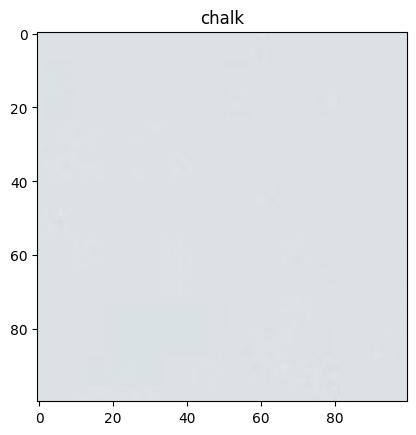

In [11]:
# read image
path = 'colors'
colors = os.listdir(path)
color = random.choice(colors)
imgs = os.listdir(os.path.join(path,color))
img = random.choice(imgs)
img = os.path.join(path,color,img)

print('reading image: ',img)
img = cv2.imread(img)

roi = crop_roi(img)

plt.imshow(roi)
plt.title(color)

In [9]:
path = 'colors'
colors = os.listdir(path)

for c in colors:
    # create floder
    if not os.path.exists(os.path.join(path2,c)):
        os.mkdir(os.path.join(path2,c))
    
    # list image
    imgs =  os.listdir(os.path.join(path,c))
    
    # crop images
    for i in imgs:
        img_path = os.path.join(path,c,i)
        img = cv2.imread(img_path)
        roi = crop_roi(img)
        cv2.imwrite(os.path.join(path2,c,i),roi)

In [25]:
path = 'colors'
colors = os.listdir(path)

for c in colors:
    # list images
    imgs =  os.listdir(os.path.join(path,c))
    print(f'{c}:{len(imgs)}')

sage:117
sand:117
charcoal:10
sky:135
chalk:1


# image augmentation

In [17]:
import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

In [18]:
augmentation = iaa.Sequential([
    # 1. Flip
    iaa.Fliplr(0.5),
    iaa.Flipud(0.5),
    
    # 2. Linearcontrast
    iaa.LinearContrast((0.6, 1.4)),
    
    # 3. Perform methods below only sometimes
    iaa.Sometimes(0.5,
                  
                  
        # 4. GaussianBlur
        iaa.GaussianBlur((0.0, 3.0))
        )
    ])

In [24]:
path3= 'augs'

N = 1000
color='sage'
img_number = len(os.listdir(os.path.join(path2,color)))
m = N//img_number


8

In [21]:
img_number

1